# 12 - Optimizers x Learning Rates

**Section:** FNNs | **Prereqs:** `FNNs/MNISTDepthVsBreadth.ipynb` | **Next:** `FNNs/MinMaxMNIST.ipynb`

A 3 x 6 grid: SGD, RMSprop and Adam, each at six learning rates spaced
logarithmically from 1e-4 to 1e-1. 18 training runs, one plot.

**Why log spacing.** Learning rate matters by order of magnitude, not by
increment. 0.001 vs 0.01 is a real difference; 0.001 vs 0.002 is noise. Every
learning-rate search should be logarithmic.

**What the curves say**
- **SGD** needs a large learning rate and is the most sensitive to getting it wrong.
- **RMSprop / Adam** normalise each parameter's step by a running estimate of its
  gradient magnitude, so they work over a much wider range - but they *diverge*
  at high learning rates where SGD is still fine.
- There is no universally best optimizer, only a best (optimizer, lr) pair. The
  mechanics of each are in `Metaparameters/`.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset

from torchvision.transforms import ToTensor
from torchvision.datasets import MNIST

In [2]:
data = MNIST(
    root='./data',        # Directory to store the dataset
    train=True,           # Load the training set
    download=True,
    transform = ToTensor()
)

test_data =  MNIST(
    root='./data',        # Directory to store the dataset
    train=False,           # Load the training set
    download=True,
    transform = ToTensor()
)

100%|██████████| 9.91M/9.91M [00:00<00:00, 39.1MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 1.02MB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 9.87MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 11.9MB/s]


In [3]:
# Six learning rates, log-spaced from 1e-4 to 1e-1. np.logspace takes the
# EXPONENTS, hence the log10() calls on the endpoints.
learning_rates = np.logspace(np.log10(0.0001), np.log10(0.1), 6)

In [4]:
# Flatten MNIST to 784-vectors; raw 0-255 values, unscaled.
label = data.targets.to('cuda')
data = data.data.view(-1,784).float()

test_label = test_data.targets.to('cuda')
test_data = test_data.data.view(-1,784).float()

In [5]:
train_data = TensorDataset(data,label)
test_data = TensorDataset(test_data,test_label)

bs = 32
data_loader = DataLoader(train_data, batch_size=bs, drop_last=True, shuffle=True)
test_loader = DataLoader(test_data, batch_size=test_data.tensors[0].shape[0])

In [6]:
# A smaller net than before (784-64-32-16-10). Deliberately: the experiment is
# about optimizers, so training has to be cheap enough to repeat 18 times.
# The output is RAW LOGITS, to pair with the CrossEntropyLoss used below.
# (An earlier version ended in log_softmax, which double-counts the softmax when
# fed to CrossEntropyLoss and reports meaningless loss values.)
class model(nn.Module):
  def __init__(self):
    super().__init__()

    self.input_layer = nn.Linear(784, 64)

    self.fc1 = nn.Linear(64,32)

    self.fc2 = nn.Linear(32,16)

    self.output_layer = nn.Linear(16,10)


  def forward(self,x):

    x = F.relu(self.input_layer(x))

    x = F.relu(self.fc1(x))

    x = F.relu(self.fc2(x))

    return self.output_layer(x)

In [7]:
# A factory that builds the requested optimizer for a given model and lr.
# Note all three are constructed on every call, then one is returned. Wasteful
# but harmless - an optimizer allocates nothing until step() runs.
def getOptim(model,optimName, lr):
  optims = {
      "Adam" : torch.optim.Adam(model.parameters(), lr = lr),
      "SGD" : torch.optim.SGD(model.parameters(), lr = lr),
      "RMSprop" : torch.optim.RMSprop(model.parameters(), lr = lr)
  }

  return optims[optimName]

In [10]:
# The sweep's training function. It takes the optimizer NAME so the loop below
# can vary it.
# CrossEntropyLoss applies log_softmax internally, so the model must emit raw
# logits - which it now does. Feeding it log_softmax output applies the softmax
# twice: it still trains, badly, and the reported loss means nothing.
def train_model(optimName, lr):

  classifier = model().to('cuda')

  epochs = 50

  lossFunc = nn.CrossEntropyLoss()
  optimizer = getOptim(classifier,optimName,lr)

  test_acc = []
  train_acc = []
  losses = torch.zeros(epochs)


  for i in range(epochs):

    classifier.train()
    batch_acc = []
    batch_loss = []

    for x,y in data_loader:

      x = x.to('cuda') # Move data to GPU
      yhat = classifier(x)

      loss = lossFunc(yhat,y)
      batch_loss.append(loss.item())


      optimizer.zero_grad()
      loss.backward()
      optimizer.step()

      batch_acc.append(100 * torch.mean( (torch.argmax(yhat,dim = 1) == y).float()).cpu() )

    train_acc.append(np.mean(batch_acc))
    losses[i] = np.mean(batch_loss)

    if i % 10 == 0 or i == epochs-1:
      print(f"Epoch {i} Optim {optimName}, LR {lr}: Loss = {losses[i].item()}")

    classifier.eval()
    with torch.no_grad():
      X,Y = next(iter(test_loader))
      X = X.to('cuda') # Move test data to GPU
      Preds = torch.argmax(classifier(X), dim = 1)
      test_acc.append( 100 * torch.mean( (Preds == Y).float()).cpu() )


  print()
  return losses, train_acc, test_acc

In [11]:
# 3 optimizers x 6 learning rates = 18 models trained from scratch.
optimizers = ["RMSprop", 'SGD', "Adam"]

x, y = len(optimizers), len(learning_rates)

train_acc = np.zeros((x, y),dtype=object)
test_acc = np.zeros((x, y),dtype=object)
losses = np.zeros((x, y),dtype=object)

for i in range(x):
    for j in range(y):
        loss, train, test = train_model(optimizers[i], learning_rates[j])
        train_acc[i][j] = train
        test_acc[i][j] = test
        losses[i][j] = loss

Epoch 0 Optim RMSprop, LR 0.0001: Loss = 0.42466187477111816
Epoch 10 Optim RMSprop, LR 0.0001: Loss = 0.04185894876718521
Epoch 20 Optim RMSprop, LR 0.0001: Loss = 0.014590093865990639
Epoch 30 Optim RMSprop, LR 0.0001: Loss = 0.006966583896428347
Epoch 40 Optim RMSprop, LR 0.0001: Loss = 0.004057909362018108
Epoch 49 Optim RMSprop, LR 0.0001: Loss = 0.003230724949389696

Epoch 0 Optim RMSprop, LR 0.00039810717055349735: Loss = 0.33923882246017456
Epoch 10 Optim RMSprop, LR 0.00039810717055349735: Loss = 0.0403771735727787
Epoch 20 Optim RMSprop, LR 0.00039810717055349735: Loss = 0.02114245668053627
Epoch 30 Optim RMSprop, LR 0.00039810717055349735: Loss = 0.01705353893339634
Epoch 40 Optim RMSprop, LR 0.00039810717055349735: Loss = 0.012198394164443016
Epoch 49 Optim RMSprop, LR 0.00039810717055349735: Loss = 0.010807502083480358

Epoch 0 Optim RMSprop, LR 0.001584893192461114: Loss = 0.5758390426635742
Epoch 10 Optim RMSprop, LR 0.001584893192461114: Loss = 0.10332316160202026
Epoch

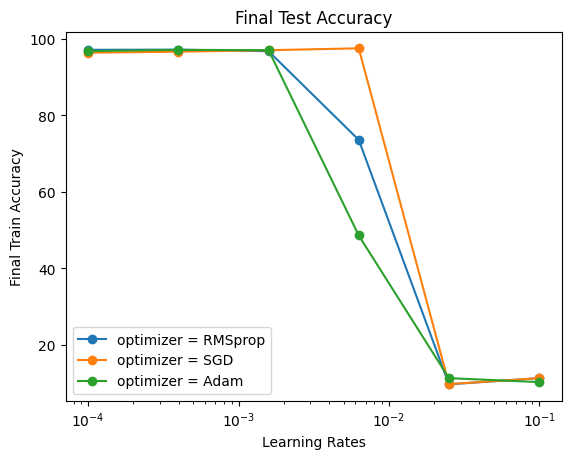

In [15]:
# The headline plot: final TEST accuracy vs learning rate, one line per
# optimizer, log x-axis. Each optimizer has its own usable band; outside it
# accuracy collapses to about 10% (chance on 10 classes).
for i in range(len(optimizers)):
    final_acc = [test_acc[i][j][-1] for j in range(len(learning_rates))]
    plt.plot(learning_rates, final_acc, "o-", label=f"optimizer = {optimizers[i]}")

plt.title("Final Test Accuracy")
plt.xlabel("Learning Rates")
plt.xscale('log')
plt.ylabel("Final Test Accuracy")
plt.legend();

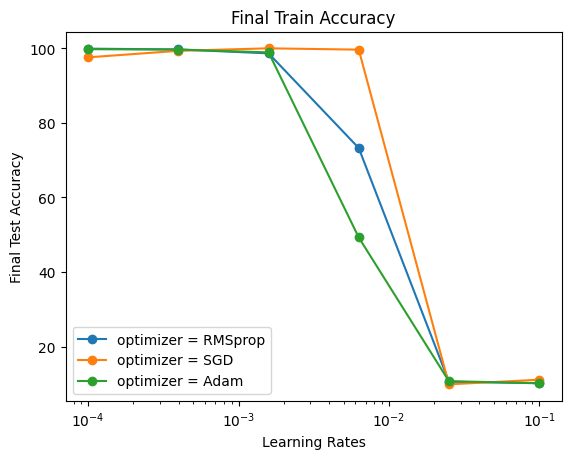

In [16]:
# The same for TRAIN accuracy. Wherever train is high and test is not, the
# model memorised rather than generalised.
for i in range(len(optimizers)):
    final_acc = [train_acc[i][j][-1] for j in range(len(learning_rates))]
    plt.plot(learning_rates, final_acc, "o-", label=f"optimizer = {optimizers[i]}")

plt.title("Final Train Accuracy")
plt.xlabel("Learning Rates")
plt.xscale('log')
plt.ylabel("Final Train Accuracy")
plt.legend();